DUVIDAS \
1.no kaggle diz que a key é o unique identifyer mas entao o que é a primeira coluna e podemos apagar a key pq é igual á outra \
2.lidar com os null fare values
3. apagamos os negative fare amounts?

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b> Machine Learning II - Project 1</b></h1>
<br>

<h1 style="margin-top:5px; color:#0047AB;"><b>"Uber Fares" </b></h1>

<h2 style="color:#0047AB; margin-top:-5px;"><b>Data Preprocessing & Exploratory Analysis</b></h2>

    
<b>Carlota Marto</b> — 20241729</li>\
<b>Francisca Teixeira</b> — 20241702</li>
</ul>
<h4>LCD  —  Teachers: Ivo Bernardo  — 2025/26 </h4>

</div>


<div style="background-color:#EFF5FF; padding:15px; border-radius:10px;">

**Table of Contents**

**1.Introduction**

1.1. Project Context and Goal

**Part A – Data Understanding & Cleaning**

2.1. Imports\
2.2. Preprocessing Data
<ul style="margin-top:-10px;">
    
  2.2.1. Duplicate Records \
  2.2.2  Handling Inconsistencies \
  2.2.3. Missing Values - Categorical(3) / Numerical (3)\
  2.2.4. Outliers  \
  2.2.5. Adjusting Data Types 
</ul>

**Part B – Feature Engineering & ABT Construction**

3.1. Static attributes (demographics)\
3.2. Aggregated behavior from all visits\
3.3. Recency & activity\
3.4.  ABT exportation


**Part C – Exploratory Visualization & Insights**

4.1.  Uber demographics: Age, Gender, and income
distributions\
4.2. Department & Service Usage\
4.3. Satisfaction: Department and Patient Segment \
4.4. Other plots 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1. Introduction </b></h3>


 <div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> 1.1. Project Context and Goal


Uber operates on a massive scale, with millions of trips being made every day. Accurate fare prediction is crucial for Uber to optimize its pricing models, enhance user experience, and manage its operational resources effectively. The challenge lies in predicting the fare of a trip based on various parameters such as the trip's distance, time of day, number of passengers, and more.

In this project, we aim to explore and model Uber’s fare prediction system. This will involve performing data preprocessing, understanding the patterns in the data, and building predictive models. The goal is to understand the underlying factors influencing Uber fares and develop a system that can predict fares with high accuracy.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>Part A – Data Understanding & Cleaning </b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.1 Imports

Import of Necessary Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

Import of the given Dataset:

In [2]:
df = pd.read_csv('uber.csv', index_col = 0)
print("The dataset has {} rows and {} columns".format(df.shape[0], df.shape[1]))
df.head()

The dataset has 200000 rows and 8 columns


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


**Atributes description:** \
**key:** Unique trip identifier.\
**fare_amount:** Cost of trip (in USD).\
**pickup_datetime:** Timestamp of trip start.\
**passenger_count:** Number of passengers.\
**pickup_longitude & pickup_latitude:** Initial pickup coordinates.\
**dropoff_longitude & dropoff_latitude:** Drop-off coordinates.

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2. Preprocessing Data
   

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.1. Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 24238194 to 11951496
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  object 
 1   fare_amount        200000 non-null  float64
 2   pickup_datetime    200000 non-null  object 
 3   pickup_longitude   200000 non-null  float64
 4   pickup_latitude    200000 non-null  float64
 5   dropoff_longitude  199999 non-null  float64
 6   dropoff_latitude   199999 non-null  float64
 7   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 13.7+ MB


In [4]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

The `pickup_datetime` column was originally stored as an object (string).  
It is converted to a proper datetime format to enable time-based analysis such as extracting year, month, day, or hour.


In [5]:
df['passenger_count'] = df['passenger_count'].astype('int8')

The `passenger_count` column is converted from `int64` to `int8` to reduce memory usage.

Since passenger counts are small values, using a smaller integer type is more efficient without losing information.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 24238194 to 11951496
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                200000 non-null  object             
 1   fare_amount        200000 non-null  float64            
 2   pickup_datetime    200000 non-null  datetime64[ns, UTC]
 3   pickup_longitude   200000 non-null  float64            
 4   pickup_latitude    200000 non-null  float64            
 5   dropoff_longitude  199999 non-null  float64            
 6   dropoff_latitude   199999 non-null  float64            
 7   passenger_count    200000 non-null  int8               
dtypes: datetime64[ns, UTC](1), float64(5), int8(1), object(1)
memory usage: 12.4+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fare_amount,200000.0,11.359955,9.901776,-52.000000,6.000000,8.500000,12.500000,499.000000
pickup_longitude,200000.0,-72.527638,11.437787,-1340.648410,-73.992065,-73.981823,-73.967154,57.418457
pickup_latitude,200000.0,39.935885,7.720539,-74.015515,40.734796,40.752592,40.767158,1644.421482
dropoff_longitude,199999.0,-72.525292,13.117408,-3356.666300,-73.991407,-73.980093,-73.963658,1153.572603
dropoff_latitude,199999.0,39.923890,6.794829,-881.985513,40.733823,40.753042,40.768001,872.697628
passenger_count,200000.0,1.683255,1.311677,-48.000000,1.000000,1.000000,2.000000,6.000000


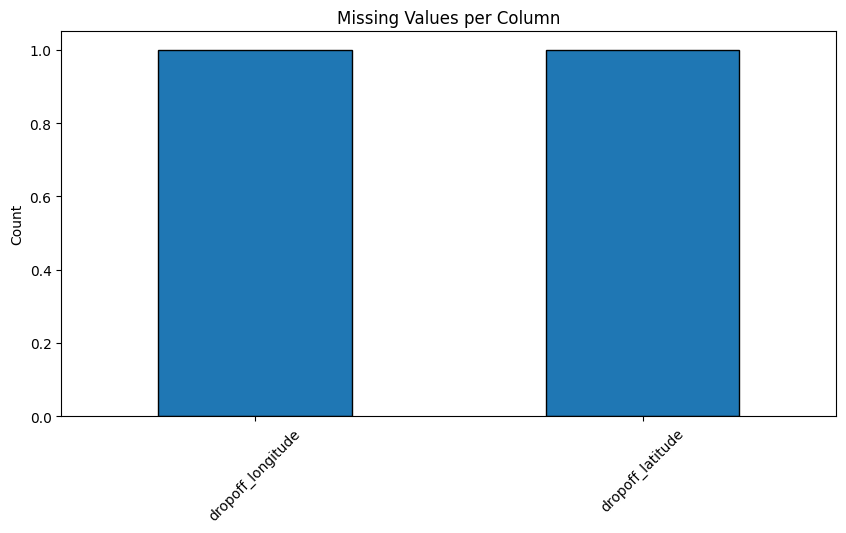

In [8]:
plt.figure(figsize=(10,5))

missing = df.isna().sum()
missing = missing[missing > 0]

missing.plot(kind='bar', edgecolor='black')

plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

<div style="background-color:#EFF5FD; padding:20px; border-radius:10px; border-left:8px">

### Missing Values per Column

The bar chart above visualizes the presence of missing values in the dataset. As seen, two columns — `dropoff_longitude` and `dropoff_latitude` — contain missing values. This is a crucial aspect of data cleaning, as missing data can significantly affect the quality of the analysis.

In this case, the missing values are likely related to incomplete trips or erroneous data entries, and they will need to be addressed during preprocessing. Methods like imputation or removal of rows can be used depending on the situation.

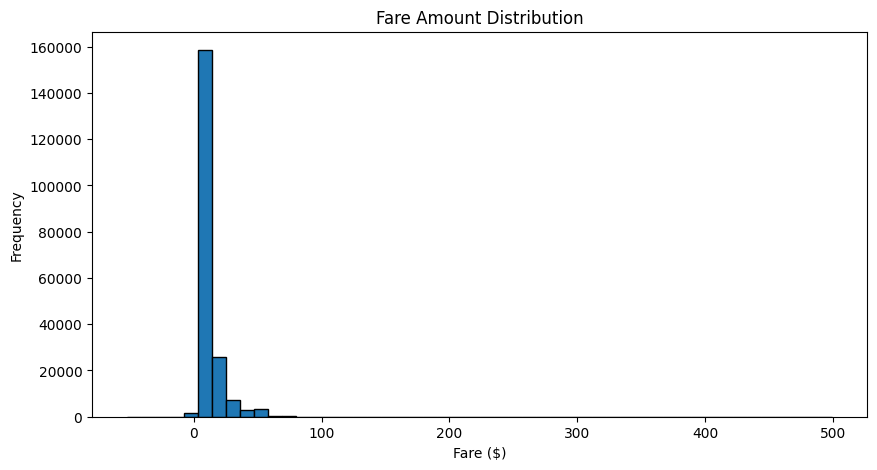

In [9]:
plt.figure(figsize=(10,5))

plt.hist(df['fare_amount'], bins=50, edgecolor='black')

plt.title('Fare Amount Distribution')
plt.xlabel('Fare ($)')
plt.ylabel('Frequency')

plt.show()

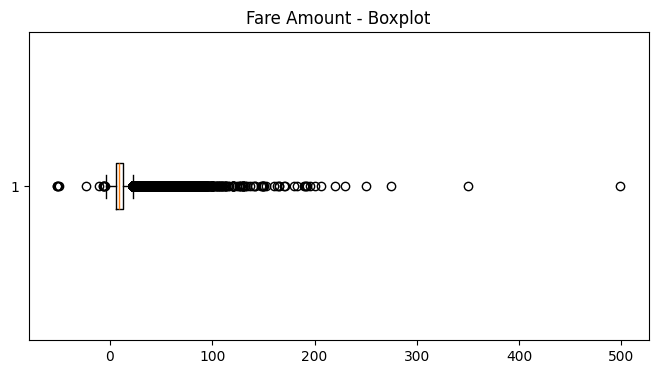

In [10]:
plt.figure(figsize=(8,4))

plt.boxplot(df['fare_amount'], vert=False)

plt.title('Fare Amount - Boxplot')

plt.show()

<div style="background-color:#EFF5FD; padding:20px; border-radius:10px; border-left:8px">

### Fare Amount Distribution

The histogram above illustrates the distribution of Uber fare amounts in the dataset. From the plot, we can observe the following key insights:

- **Skewed Distribution**: The distribution is highly skewed to the right, meaning most of the trips have a low fare amount. A large number of trips are inexpensive, which is typical for short trips or those with fewer passengers.
  
- **Outliers**: There are a few extreme outliers where the fare exceeds $100. These could represent long trips or potentially erroneous data points that need further investigation.

- **Frequency**: A very high frequency of trips fall within the lower fare range, indicating that the dataset is dominated by short, inexpensive trips. This is consistent with the general trend of urban ride-hailing services.

This distribution will influence how we approach data preprocessing, particularly in handling outliers and understanding the overall pricing structure.

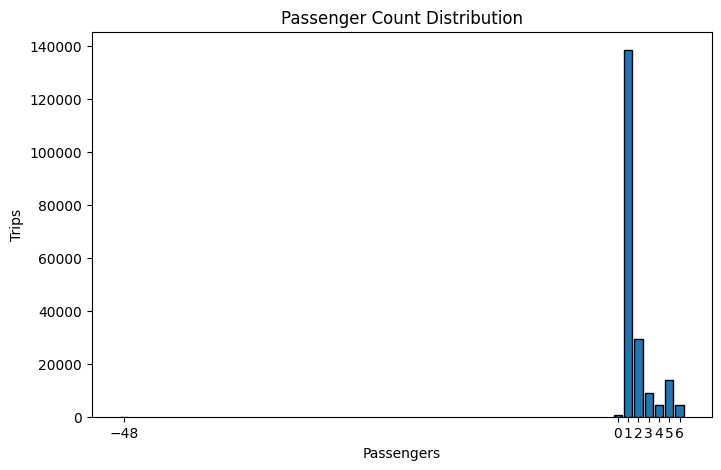

In [11]:
plt.figure(figsize=(8,5))

counts = df['passenger_count'].value_counts().sort_index()

plt.bar(counts.index, counts.values, edgecolor='black')

plt.title('Passenger Count Distribution')
plt.xlabel('Passengers')
plt.ylabel('Trips')

plt.xticks(counts.index)

plt.show()

<div style="background-color:#EFF5FD; padding:20px; border-radius:10px; border-left:8px">

### Passenger Count Distribution

The bar chart above displays the distribution of passenger counts for the Uber trips in the dataset. Some key observations:

- **Dominance of Single Passengers**: The vast majority of trips (over 100,000) have only **1 passenger**, making it the most common passenger count. This suggests that Uber is predominantly used for solo trips.

- **Less Frequent Higher Passenger Counts**: As the passenger count increases, the number of trips decreases significantly. This indicates that trips with more passengers (such as 3, 4, 5, or 6 passengers) are much less frequent.

- **Negative Values**: The presence of negative values on the passenger count axis (e.g., -48) suggests the need for data cleaning. These negative values are likely data errors that should be addressed and removed.

This distribution helps us understand Uber's usage patterns and also signals potential data quality issues with negative passenger counts that need to be corrected.

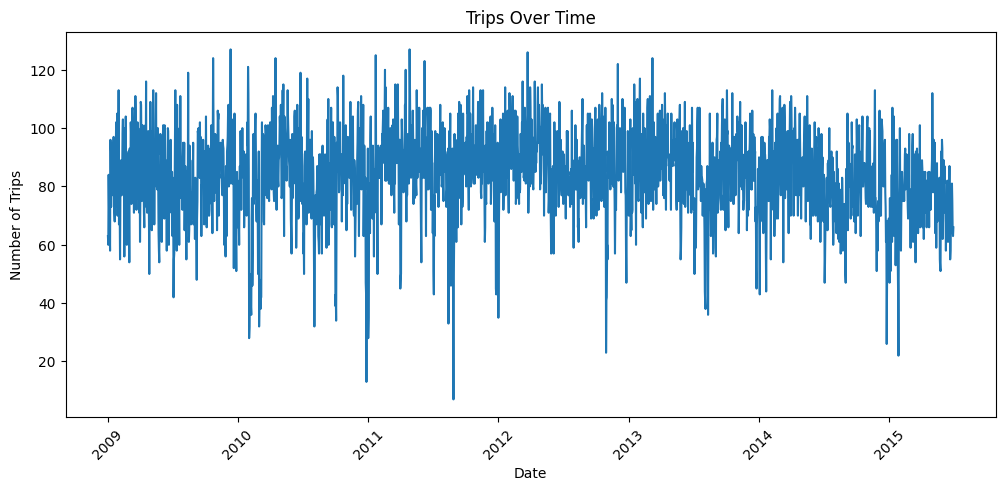

In [12]:
trips_per_day = df.groupby(df['pickup_datetime'].dt.date).size()

plt.figure(figsize=(12,5))
plt.plot(trips_per_day)

plt.title('Trips Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Trips')

plt.xticks(rotation=45)
plt.show()

<div style="background-color:#EFF5FD; padding:20px; border-radius:10px; border-left:8px">

### Trips Over Time

The line plot above represents the number of Uber trips per day over time. Some key insights from the plot include:

- **General Consistency**: The number of trips remains fairly consistent across the years, with minor fluctuations. The general trend does not indicate any significant rise or fall in the number of trips on a year-to-year basis.
  
- **Seasonal Variations**: There are visible spikes in the number of trips on certain days, indicating daily variations in Uber usage, likely due to peak times, such as weekends or holidays.

- **Small Long-Term Fluctuations**: There is some visible fluctuation between 2009 to 2015, but no major upward or downward trend over the long term. These variations may be due to local events, weather conditions, or specific promotions affecting the trips.

This plot provides valuable insight into Uber's usage patterns, which is crucial for understanding demand over time and planning for capacity management.

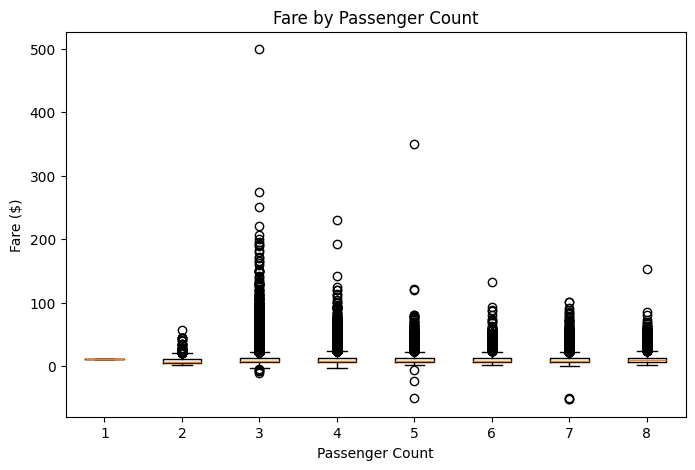

In [13]:
plt.figure(figsize=(8,5))

plt.boxplot([df[df['passenger_count']==i]['fare_amount'] 
             for i in sorted(df['passenger_count'].unique())])

plt.title('Fare by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare ($)')

plt.show()

<div style="background-color:#EFF5FD; padding:20px; border-radius:10px; border-left:8px">

### Fare by Passenger Count

The box plot above visualizes the relationship between the fare amount and the number of passengers. Some key insights:

- **Fare Range by Passenger Count**: For the majority of trips, the fare amount increases as the number of passengers increases. However, this is not a perfect correlation, as there are still a few low-cost trips with higher passenger counts (e.g., 4 or 5 passengers).
  
- **Outliers**: Each passenger count has some outliers, particularly at higher fares. Trips with more than 4 passengers show significant outliers, with fares exceeding $200, especially for 3-5 passengers.

- **Median Fare by Passenger Count**: The median fare remains relatively low for most passenger counts (1 to 3), but the fare for trips with 4 passengers or more shows slight increases in median values.

- **Interquartile Range (IQR)**: The box plot highlights that the interquartile range (IQR) is consistently narrow for trips with fewer passengers, suggesting more uniformity in fare amounts for small groups. In contrast, higher passenger counts exhibit a wider IQR, showing greater variability in fares.

This plot helps us understand how Uber fares are influenced by the number of passengers, revealing that while fares generally rise with passenger count, there is significant variability and a few extreme outliers.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.2. How to Handle Duplicate Records

We chose to handle the **duplicate records firstly** so that those records do not interfere with the imputation of the missing values.

In [14]:
df.duplicated()

24238194    False
27835199    False
44984355    False
25894730    False
17610152    False
            ...  
42598914    False
16382965    False
27804658    False
20259894    False
11951496    False
Length: 200000, dtype: bool

In [15]:
duplicate_records = df[df.duplicated(keep = False)]
duplicate_records.shape
#these two lines shows us the duplicate records in the dataset

(0, 8)

There aren´t duplicate records.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.3. Handling Inconsistent Records

Datasets frequently contain logical inconsistencies (for instance, negative passenger count). These records are technically present in the dataset but do not make any sense in a real-world context. This step is dedicated to identifying and correcting these errors, which are different from missing data.

We chose to handle these inconsistencies before the imputation of the missing values as we often use conditional imputation and, if they are left uncorrected, it distorts the groups statistics, such as the median, mean or mode. So in this way we ensure that the statistical basis is clean, stable and accurate.

In [16]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5


The column 'key' doesn´t add info necessary (is the same time as pickup_datetime with millisecond).

In [17]:
df.drop(columns='key', inplace=True)
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...
42598914,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1
16382965,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1
27804658,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2
20259894,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.3. Handling Inconsistent Records 
    <b>- First Rule: Negative Values - Every variable that corresponds to a price, time or number of passagers cannot be negative.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Price** - fare_amount

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Null Values: 

In [18]:
null_fares = df[df['fare_amount'] == 0]
null_fares

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
25344154,0.0,2015-04-22 23:25:07+00:00,-73.658897,40.805199,-73.658897,40.805199,1
22994576,0.0,2010-03-20 02:59:51+00:00,-73.994366,40.755395,-73.998718,40.854853,2
10649069,0.0,2015-01-04 03:51:13+00:00,-73.969475,40.807503,0.000000,0.000000,2
36776406,0.0,2015-02-17 08:48:08+00:00,-73.937714,40.758541,-73.937721,40.758541,1
44172118,0.0,2015-02-13 07:35:32+00:00,0.000000,0.000000,0.000000,0.000000,5


- **25344154** - pickup and dropoff travel coordinates are the same so we consider it was a **canceled uber**. It is not an error it is just a travel that didn´t occur. 
- **22994576** - travel occur - **error**. We can estimate the fare amount.
- **10649069** - dropoff_longitude and dropoff_latitude are both 0.0. We consider an **error** because all of the other observations are in the same zone and not travel half world. We cannot estimate the fare amount.
- **36776406** - pickup_latitude and dropoff_latitude	are the same and pickup_longitude and dropoff_longitude have a 0.000007 difference so we consider that was a **canceled travel.**
- **44172118** - the other values are all in the same zone (near -73 longitude, 40 latitude), so we consider the 0.0 a **error** and not a canceled travel with coordinates 0.0. We cannot estimate the fare amount.

Droping errors and mantaining canceled travels:

In [19]:
df.drop([10649069, 44172118], axis=0, inplace=True)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Calculating Distances:

For travel nº22994576 - caultulating the travel distance for all and seeing what travel has the most parecida distance and datetime.

**Function to transform coordinates to distance:** new column

In [20]:
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 # Raio da Terra em km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    res = 2 * r * np.arcsin(np.sqrt(a))
    return res

In [21]:
df['distance_km'] = haversine_distance(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323
27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590
44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377
25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683
17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450
...,...,...,...,...,...,...,...,...
42598914,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,0.112210
16382965,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,1.875050
27804658,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,12.850319
20259894,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,3.539715


In [22]:
#Reference Values:
travel_ref = df.loc[22994576]
dist_ref = travel_ref['distance_km']
time_ref = pd.to_datetime(travel_ref['pickup_datetime'])

In [23]:
#absolute diff of distance
df_busca = df.drop(index=22994576)
df_busca['diff_dist'] = (df_busca['distance_km'] - dist_ref).abs()

In [24]:
#5 travels with diff_dist more small
top_5_dist = df_busca.nsmallest(5, 'diff_dist').copy()
top_5_dist

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,diff_dist
47542165,26.10,2012-01-06 23:28:00+00:00,-73.863085,40.768505,-73.984370,40.730335,2,11.063343,0.001947
12576258,40.33,2013-09-30 21:28:01+00:00,-73.874473,40.774075,-73.979000,40.713778,1,11.067830,0.002540
27876322,31.00,2014-09-29 14:49:26+00:00,-73.983736,40.721465,-73.872381,40.774294,1,11.068077,0.002788
7385134,37.83,2014-12-05 13:59:58+00:00,-73.862820,40.768896,-73.983818,40.730086,1,11.068562,0.003272
29823507,7.30,2012-07-15 04:48:00+00:00,-73.973625,40.755062,-73.912167,40.843065,3,11.068791,0.003502


We will choose the fare amount of **47542165** to input in **22994576** because is the travel with travel distance more similar, and the second with pickup_datetime more close.

In [25]:
df.at[22994576, 'fare_amount'] = 26.10

In [26]:
df[df.index==22994576]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
22994576,26.1,2010-03-20 02:59:51+00:00,-73.994366,40.755395,-73.998718,40.854853,2,11.065289


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Negative Fare Amount:

In [27]:
negative_fares = ['fare_amount']
df[((df[negative_fares]) < 0).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
30260042,-5.00,2015-03-03 23:07:41+00:00,-73.992249,40.748936,-73.988518,40.748180,1,0.325306
51325304,-3.30,2010-02-11 21:47:10+00:00,-73.952725,40.768235,-73.949928,40.772208,2,0.500646
50284253,-3.50,2015-05-01 14:43:02+00:00,-73.982430,40.775024,-73.981750,40.778439,1,0.383918
26673143,-49.57,2010-03-09 08:26:10+00:00,-73.972772,40.785657,-73.972867,40.785500,5,0.019203
10267585,-23.70,2010-03-12 08:49:10+00:00,-73.952740,40.768233,-74.007028,40.707338,3,8.171296
51135168,-52.00,2015-03-20 21:31:14+00:00,-74.000359,40.728729,-74.005699,40.728680,5,0.450054
21688700,-7.30,2010-03-09 20:25:10+00:00,-73.952623,40.766942,-73.953787,40.784882,1,1.997243
13971251,-52.00,2015-02-23 19:26:44+00:00,-73.984665,40.759026,0.000000,0.000000,5,8666.246939
40714150,-6.90,2010-02-23 18:52:10+00:00,-73.988727,40.736445,-73.977622,40.750487,1,1.820225
34933571,-5.70,2010-02-12 10:50:10+00:00,-73.977300,40.742783,-73.988837,40.747465,3,1.102572


In [28]:
df[((df[negative_fares]) < 0).any(axis=1)].shape[0]

17

We cannot know if it is a mistake, if the real value is equal but positive, so we delete.

In [29]:
df = df[~(df[negative_fares] < 0).any(axis=1)]

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Latitude and Longitude Values** : \
latitude: -90° to +90° \
longitude: -180° to +180

In [30]:
import folium

sample_df = df.sample(500)

m = folium.Map(location=[40.7, -74], zoom_start=11)

for _, row in sample_df.iterrows():
    # pickup (blue)
    folium.CircleMarker(
        [row['pickup_latitude'], row['pickup_longitude']],
        radius=2,
        color='blue',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)
    
    # dropoff (red)
    folium.CircleMarker(
        [row['dropoff_latitude'], row['dropoff_longitude']],
        radius=2,
        color='red',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

#
legend_html = '''
<div style="
position: fixed; 
bottom: 50px; left: 50px; width: 160px; height: 90px; 
background-color: white; border:2px solid grey; z-index:9999; 
font-size:14px; padding:10px;
">
<b>Legend</b><br>
<i style="color:blue;">●</i> Pickup<br>
<i style="color:red;">●</i> Dropoff
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))

m

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Pickup

In [31]:
invalid_coordinates = df[df['pickup_longitude']< -180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
42931506,4.9,2012-04-28 00:58:00+00:00,-748.016667,40.739957,-74.003570,40.734192,1,3828.760217
1055960,33.7,2011-11-05 23:26:00+00:00,-735.200000,40.770092,-73.980187,40.765530,1,4852.352520
33249845,15.7,2011-11-05 00:22:00+00:00,-1340.648410,1644.421482,-3356.666300,872.697628,1,16409.239135
16826862,12.9,2011-10-14 19:04:00+00:00,-736.216667,40.767035,-73.982377,40.725562,1,4773.694612
9421322,7.3,2009-08-26 11:55:00+00:00,-768.550000,40.757812,-73.997040,40.740007,1,2136.043688
25264921,4.1,2010-05-12 12:19:00+00:00,-735.433332,40.740605,-74.006373,40.739607,1,4838.094257
44787414,4.1,2012-07-21 16:19:00+00:00,-736.400000,40.774307,-73.982215,40.769672,5,4757.216153


We consider that all above observations minus the third are decimal point error. So we will correct all and eliminate '33249845'. 

In [32]:
df.drop([33249845], axis=0, inplace=True)

In [33]:
df.loc[df['pickup_longitude'] < -180, 'pickup_longitude'] *= 0.1

In [34]:
df.loc[42931506]

fare_amount                                4.9
pickup_datetime      2012-04-28 00:58:00+00:00
pickup_longitude                    -74.801667
pickup_latitude                      40.739957
dropoff_longitude                    -74.00357
dropoff_latitude                     40.734192
passenger_count                              1
distance_km                        3828.760217
Name: 42931506, dtype: object

In [35]:
invalid_coordinates = df[df['pickup_longitude']> 180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


All checked.

In [36]:
invalid_coordinates = df[df['pickup_latitude']< -90]
invalid_coordinates	

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [37]:
invalid_coordinates = df[df['pickup_latitude']> 90]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
14257861,8.1,2012-03-11 07:24:00+00:00,-73.960828,404.433332,-73.988357,40.769037,1,407.457236
2849369,8.5,2012-06-13 05:45:00+00:00,-73.951385,401.066667,-73.982110,40.754117,1,34.849750
23566642,16.1,2011-05-18 13:24:00+00:00,57.418457,1292.016128,1153.572603,-881.985513,1,2246.893301


In [38]:
df.drop([23566642], axis=0, inplace=True)

In [39]:
df.loc[df['pickup_latitude']> 90, 'pickup_latitude'] *= 0.1

In [40]:
df.loc[14257861]

fare_amount                                8.1
pickup_datetime      2012-03-11 07:24:00+00:00
pickup_longitude                    -73.960828
pickup_latitude                      40.443333
dropoff_longitude                   -73.988357
dropoff_latitude                     40.769037
passenger_count                              1
distance_km                         407.457236
Name: 14257861, dtype: object

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Dropoff

In [41]:
invalid_coordinates = df[df['dropoff_longitude']< -180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
5634081,15.7,2012-06-16 10:04:00+00:00,-74.016055,40.715155,-737.916665,40.697862,2,4644.267681


In [42]:
df.loc[df['dropoff_longitude']< -180, 'dropoff_longitude'] *= 0.1

In [43]:
invalid_coordinates = df[df['dropoff_longitude']> 180]
invalid_coordinates 

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [44]:
invalid_coordinates = df[df['dropoff_latitude']< -90]
invalid_coordinates	

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [45]:
invalid_coordinates = df[df['dropoff_latitude']> 90]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
39981694,13.7,2012-01-20 11:50:00+00:00,-74.011042,40.70978,-73.983163,493.533332,4,10321.507661


In [46]:
df.loc[df['dropoff_latitude']> 90, 'dropoff_latitude'] *= 0.1

VER ISTO AQUI!!

In [47]:
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
39981694,13.7,2012-01-20 11:50:00+00:00,-74.011042,40.70978,-73.983163,493.533332,4,10321.507661


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Time** - pickup_datetime

In [48]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

df['pickup_datetime'].isna().sum()

0

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Nº passagers** - passenger_count

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Negative Count

In [49]:
negative_count = ['passenger_count']
df[((df[negative_count]) < 0).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
35893772,11.7,2010-12-28 08:20:00+00:00,-73.937795,40.758498,-73.937835,40.758415,-48,0.009825


In [50]:
df.drop([35893772], axis=0, inplace=True)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">Not Integers

In [51]:
not_int = ['passenger_count']
df[((df[not_int]) %1 != 0).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Max 7 Passengers

In [52]:
max_count = ['passenger_count']
df[((df[max_count]) > 7).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


Passenger_count all good.

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.2. Handling Inconsistent Records <b>- Second Rule: 

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. How to Handle Missing Values 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
Firstly, we need to understand how many missing values are in our dataset. With this function, we are able to see how many are in each column.

In [53]:
df.isna().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
distance_km          1
dtype: int64

In [54]:
df[df['dropoff_longitude'].isna()]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
32736015,24.1,2013-07-02 03:51:57+00:00,-73.950581,40.779692,NaN,NaN,0,NaN


The two missing values in the dataset are in the row with index 32736015, that are the coordinates of dropoff, so we will remove this row.

In [55]:
df = df.drop(32736015)

In [56]:
df.isna().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
distance_km          0
dtype: int64

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
<b>2.2.5. Outliers - How should we treat them?

Before doing any steps regarding the outliers, we need to understand the data and its purpose. There are a lot of things that we are able to do: 
- We can fix outliers values when values are clearly unrealistic by replacing their values with the median.
- We can also just remove them if they are few, clearly erros or just not important fot the analysis.
- However, we can winsorize extreme values instead of removing them. This keeps data however reduces distortion.
- We can use transformation , by applying the log(x) or the sqrt(x) functions.

Note: It is important to understand the context of outliers before doing any changes or steps regarding them.

Basic statistics of numerical columns (all columns):

In [57]:
print("Basic Statistics")
print(df.describe())

Basic Statistics
         fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  199977.000000     199977.000000    199977.000000      199977.000000   
mean       11.362499        -72.502094        39.918094         -72.512643   
std         9.897173         10.448958         6.129912          10.408661   
min         0.000000        -93.824668       -74.015515         -75.458979   
25%         6.000000        -73.992065        40.734792         -73.991407   
50%         8.500000        -73.981822        40.752590         -73.980092   
75%        12.500000        -73.967152        40.767157         -73.963659   
max       499.000000         40.808425        48.018760          40.831932   

       dropoff_latitude  passenger_count    distance_km  
count     199977.000000    199977.000000  199977.000000  
mean          39.922644         1.683459      20.677481  
std            6.115901         1.306929     380.213961  
min          -74.015750         0.000000       0

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Datetime 

In [58]:
# Parse datetime
print("DATETIME PROCESSING")

# Extract datetime components
df['pickup_date'] = df['pickup_datetime'].dt.date
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_year'] = df['pickup_datetime'].dt.year
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6
df['pickup_quarter'] = df['pickup_datetime'].dt.quarter

# Create day/night indicator (6 AM - 6 PM = day)
df['is_day'] = ((df['pickup_hour'] >= 6) & (df['pickup_hour'] < 18)).astype(int)

# Create weekend indicator
df['is_weekend'] = (df['pickup_dayofweek'] >= 5).astype(int)

print("Datetime features created:")
print(f"- pickup_hour: {df['pickup_hour'].nunique()} unique hours")
print(f"- pickup_dayofweek: {df['pickup_dayofweek'].nunique()} unique days")
print(f"- pickup_month: {df['pickup_month'].nunique()} unique months")
print(f"- pickup_year: {sorted(df['pickup_year'].unique())}")
print(f"- is_day: {df['is_day'].sum()} day trips, {len(df)-df['is_day'].sum()} night trips")
print(f"- is_weekend: {df['is_weekend'].sum()} weekend trips")

DATETIME PROCESSING
Datetime features created:
- pickup_hour: 24 unique hours
- pickup_dayofweek: 7 unique days
- pickup_month: 12 unique months
- pickup_year: [2009, 2010, 2011, 2012, 2013, 2014, 2015]
- is_day: 105523 day trips, 94454 night trips
- is_weekend: 56689 weekend trips


In [59]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,pickup_date,pickup_hour,pickup_day,pickup_month,pickup_year,pickup_dayofweek,pickup_quarter,is_day,is_weekend
24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,2015-05-07,19,7,5,2015,3,2,0,0
27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,2009-07-17,20,17,7,2009,4,3,0,0
44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,2009-08-24,21,24,8,2009,0,3,0,0
25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,2009-06-26,8,26,6,2009,4,2,1,0
17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,2014-08-28,17,28,8,2014,3,3,1,0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Feature Engineering

In [60]:
# Create additional features
print("\FEATURE ENGINEERING")

# Time-based features
df['hour_category'] = pd.cut(df['pickup_hour'], 
                                     bins=[0, 6, 12, 18, 24], 
                                     labels=['Late Night', 'Morning', 'Afternoon', 'Evening'],
                                     right=False)

df['day_name'] = df['pickup_dayofweek'].map({
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
})

df['month_name'] = df['pickup_month'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# Season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['pickup_month'].apply(get_season)

# Rush hour indicator (7-9 AM and 4-7 PM on weekdays)
df['is_rush_hour'] = ((~df['is_weekend'].astype(bool)) & 
                              (((df['pickup_hour'] >= 7) & (df['pickup_hour'] <= 9)) |
                               ((df['pickup_hour'] >= 16) & (df['pickup_hour'] <= 19)))).astype(int)

print("New categorical features created:")
print(f"- hour_category: {df['hour_category'].unique()}")
print(f"- day_name: {df['day_name'].unique()}")
print(f"- month_name: {df['month_name'].unique()}")
print(f"- season: {df['season'].unique()}")
print(f"- is_rush_hour: {df['is_rush_hour'].sum()} rush hour trips")

\FEATURE ENGINEERING
New categorical features created:
- hour_category: ['Evening', 'Morning', 'Afternoon', 'Late Night']
Categories (4, object): ['Late Night' < 'Morning' < 'Afternoon' < 'Evening']
- day_name: ['Thursday' 'Friday' 'Monday' 'Saturday' 'Sunday' 'Tuesday' 'Wednesday']
- month_name: ['May' 'Jul' 'Aug' 'Jun' 'Feb' 'Oct' 'Dec' 'Mar' 'Apr' 'Sep' 'Nov' 'Jan']
- season: ['Spring' 'Summer' 'Winter' 'Fall']
- is_rush_hour: 53099 rush hour trips


In [61]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,pickup_date,pickup_hour,...,pickup_year,pickup_dayofweek,pickup_quarter,is_day,is_weekend,hour_category,day_name,month_name,season,is_rush_hour
24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,2015-05-07,19,...,2015,3,2,0,0,Evening,Thursday,May,Spring,1
27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,2009-07-17,20,...,2009,4,3,0,0,Evening,Friday,Jul,Summer,0
44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,2009-08-24,21,...,2009,0,3,0,0,Evening,Monday,Aug,Summer,0
25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,2009-06-26,8,...,2009,4,2,1,0,Morning,Friday,Jun,Summer,1
17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,2014-08-28,17,...,2014,3,3,1,0,Afternoon,Thursday,Aug,Summer,1


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Exploratory Data Analysis

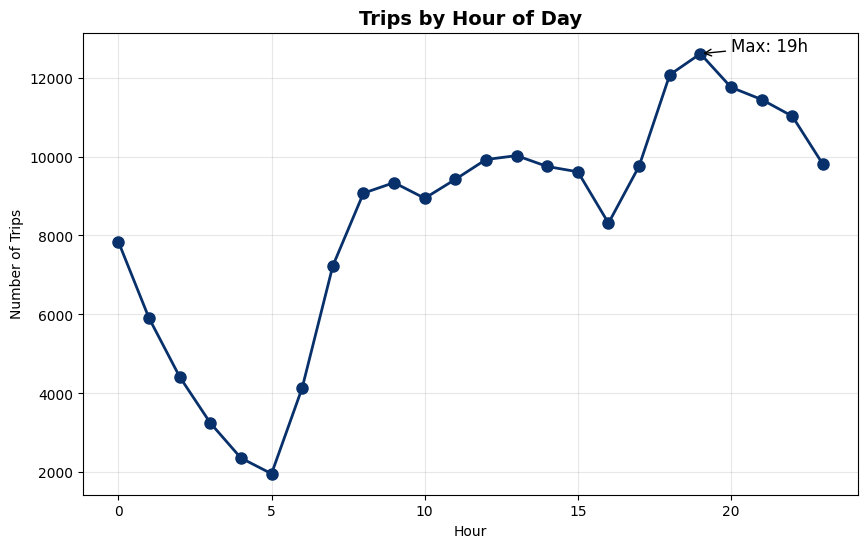

In [62]:
# Define o layout da figura
fig, ax = plt.subplots(figsize=(10, 6))

# Viagens por hora do dia
hourly_trips = df['pickup_hour'].value_counts().sort_index()
ax.plot(hourly_trips.index, hourly_trips.values, marker='o', linewidth=2, markersize=8, color='#08306b')
ax.set_title('Trips by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of Trips')
ax.grid(True, alpha=0.3)

# Adicionando anotações para picos
max_trip_hour = hourly_trips.idxmax()
max_trip_count = hourly_trips.max()
ax.annotate(f'Max: {max_trip_hour}h', 
            xy=(max_trip_hour, max_trip_count), 
            xytext=(max_trip_hour + 1, max_trip_count + 50), 
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            fontsize=12)

plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
### Trips by Hour of Day

The line plot above shows the number of Uber trips per hour of the day. Some key insights from this plot:

- **Peak Hours**: The plot reveals that the number of trips peaks around **19:00 (7 PM)**, with over 12,000 trips. This is likely a result of the evening commute or increased demand after work hours.
  
- **Low Traffic in Early Hours**: The number of trips is lowest between **4:00 AM and 6:00 AM**, which is expected as this is typically a less busy time, likely reflecting fewer passengers needing rides.

- **Steady Increase and Decrease**: From around 7:00 AM, the number of trips steadily increases throughout the morning, peaks in the evening, and then gradually decreases again.

- **Max Value**: The highest point is at **19:00 (7 PM)**, which is indicated on the plot with an annotation and arrow pointing to the corresponding time.

This analysis of trips by hour of day helps us understand when Uber experiences the highest demand, which can assist in optimizing operational and pricing strategies for Uber.

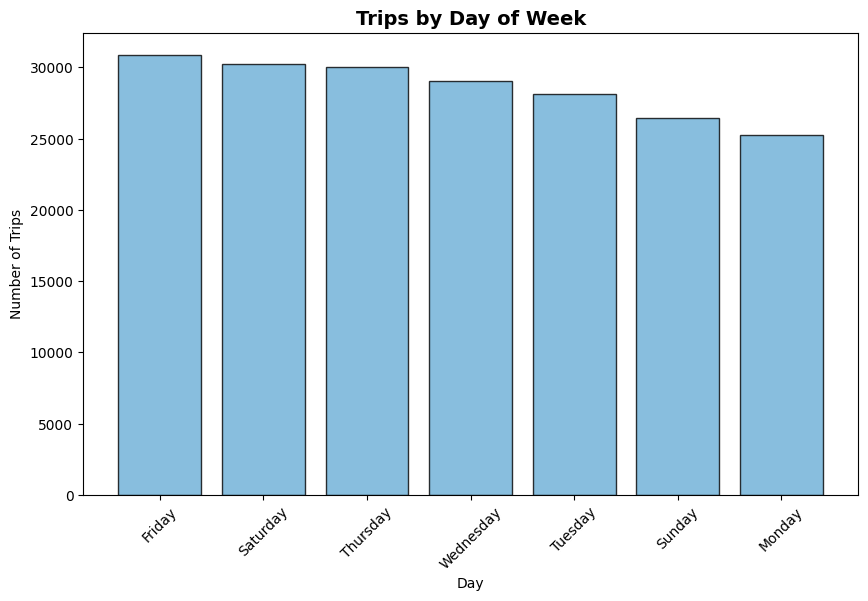

In [63]:
# Define o layout da figura
fig, ax = plt.subplots(figsize=(10, 6))

# Viagens por dia da semana
dow_trips = df['day_name'].value_counts()
ax.bar(dow_trips.index, dow_trips.values, edgecolor='black', alpha=0.8, color='#6baed6')
ax.set_title('Trips by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Trips')
ax.tick_params(axis='x', rotation=45)

plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

### Trips by Day of Week

The bar chart above shows the number of Uber trips by day of the week. Some key insights include:

- **Peak on Fridays and Saturdays**: The number of trips is highest on **Friday** and **Saturday**, with a slight dip on **Monday**. This could be due to increased activity over the weekend, especially for leisure trips, events, or social outings.
  
- **Weekday Consistency**: The number of trips is relatively consistent on weekdays (Tuesday to Thursday), suggesting steady demand for Uber services during the workweek.

- **Lower Trips on Mondays**: **Monday** shows the lowest number of trips, which might indicate fewer people using ride-hailing services due to different work routines or the beginning of the workweek.

- **Fairly Even Distribution**: Overall, the trips per day of the week do not exhibit extreme variations, indicating that Uber operates on a stable demand cycle throughout the week, with some spikes during the weekend.

This plot provides valuable insight into the weekly usage patterns of Uber, useful for understanding when demand peaks and adjusting availability accordingly.

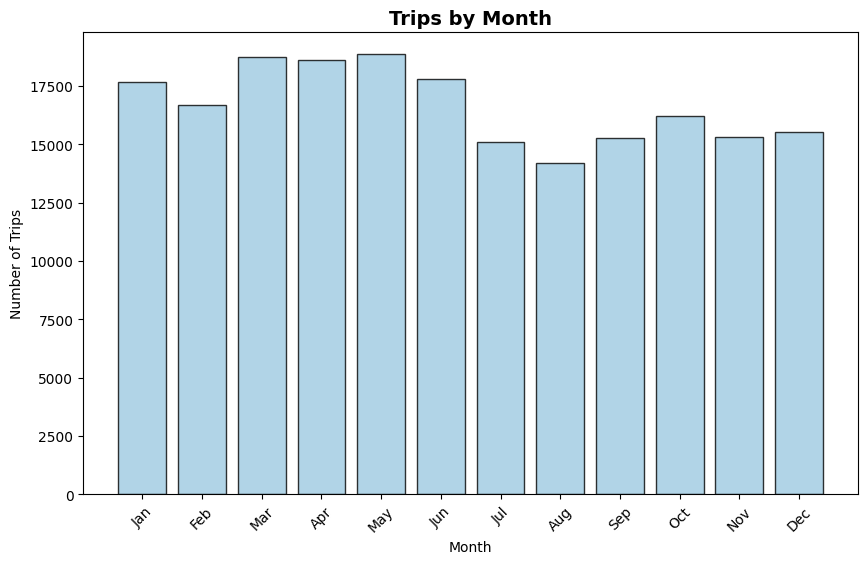

In [64]:
# Define o layout da figura
fig, ax = plt.subplots(figsize=(10, 6))

# Viagens por mês
month_trips = df['month_name'].value_counts()
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_trips = month_trips.reindex(month_order)
ax.bar(month_trips.index, month_trips.values, edgecolor='black', alpha=0.8, color='#9ecae1')
ax.set_title('Trips by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Trips')
ax.tick_params(axis='x', rotation=45)

plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

### Trips by Month

The bar chart above displays the number of Uber trips by month. Key insights include:

- **Consistent Demand**: The number of trips remains fairly consistent across all months of the year, with only slight fluctuations between months.
  
- **Peaks in Spring and Fall**: The months of **March** to **May** and **September** to **November** show slightly higher trip numbers, which could be linked to seasonal factors like increased travel or social events during these periods.

- **Lower Numbers in Winter**: **December** and **January** have the lowest number of trips, potentially due to weather-related factors or holiday periods where fewer people use Uber for daily commuting.

- **Even Distribution**: Overall, there doesn't appear to be a drastic difference between any given month, indicating that Uber’s demand is relatively steady throughout the year, with slight seasonal peaks and valleys.

This plot provides a clear understanding of how Uber's trip demand varies month-to-month, helping businesses plan for seasonal demand fluctuations.

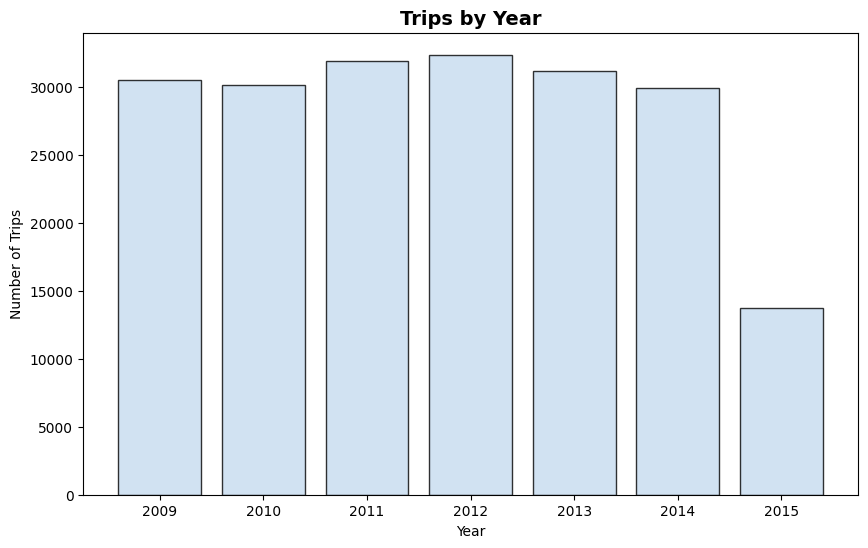

In [65]:
# Define o layout da figura
fig, ax = plt.subplots(figsize=(10, 6))

# Viagens por ano
year_trips = df['pickup_year'].value_counts().sort_index()
ax.bar(year_trips.index.astype(str), year_trips.values, edgecolor='black', alpha=0.8, color='#c6dbef')
ax.set_title('Trips by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Trips')

plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
### Key Insights

- **Fares:** Most trips are cheap, with a few expensive outliers (likely long rides).
- **Passengers:** Most rides have 1 passenger — solo trips dominate.
- **Time of day:** Fewer trips early morning, peaks in the evening (commute hours).
- **Day of week:** Fairly stable, with slightly higher activity on weekends.
- **Month:** No major seasonal changes, just small fluctuations.
- **Year:** Data is consistent over time, except for a drop in 2015 (likely incomplete data).

### Summary
Taxi usage is mostly short, low-cost, single-passenger trips, with demand following daily routines.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.4. Correlation Analysis


CORRELATION ANALYSIS
Using columns: ['fare_amount', 'passenger_count', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_dayofweek', 'is_day', 'is_weekend', 'is_rush_hour']


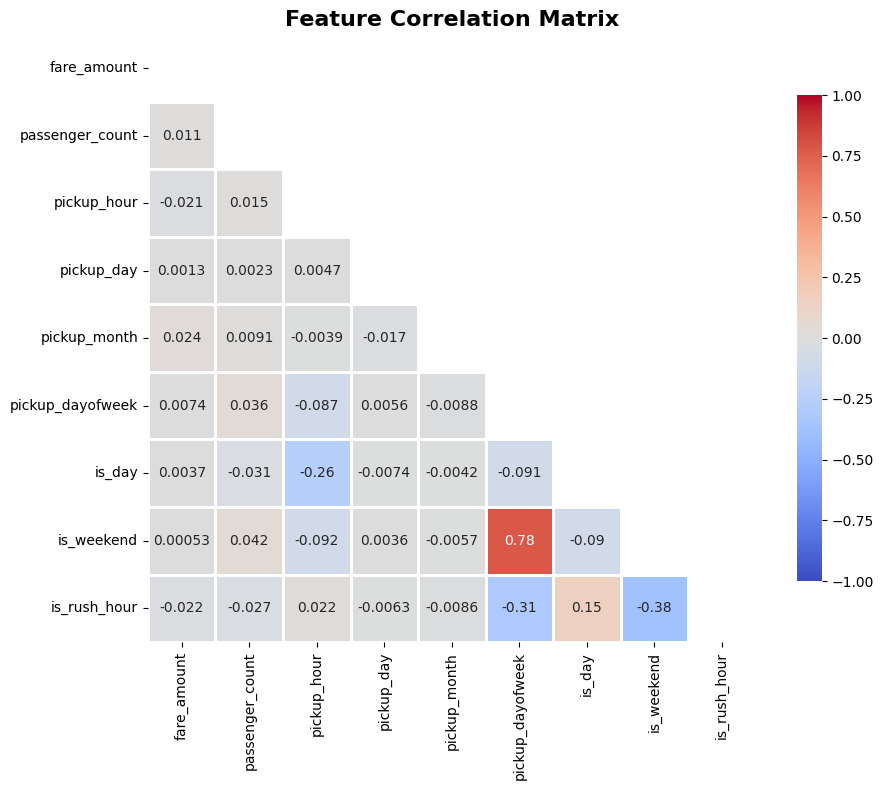


Top correlations with fare_amount:
fare_amount         1.000000
pickup_month        0.023565
passenger_count     0.011035
pickup_dayofweek    0.007429
is_day              0.003662
pickup_day          0.001337
is_weekend          0.000532
pickup_hour        -0.021468
is_rush_hour       -0.021836
Name: fare_amount, dtype: float64


In [66]:
# Correlation analysis
print("\nCORRELATION ANALYSIS")

# Select numerical columns for correlation
numerical_cols = ['fare_amount', 'passenger_count', 'pickup_hour', 'pickup_day', 
                  'pickup_month', 'pickup_dayofweek', 'is_day', 'is_weekend', 'is_rush_hour']

# Filter to only columns that exist
available_numerical_cols = [col for col in numerical_cols if col in df.columns]
print(f"Using columns: {available_numerical_cols}")

correlation_matrix = df[available_numerical_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

# Plot heatmap with mask
sns.heatmap(correlation_matrix, 
            mask=mask,  # This masks the upper triangle
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            square=True, 
            linewidths=1, 
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with fare_amount:")
if 'fare_amount' in correlation_matrix.columns:
    fare_corr = correlation_matrix['fare_amount'].sort_values(ascending=False)
    print(fare_corr)

In [67]:
pd.set_option('display.max_columns', None)
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,pickup_date,pickup_hour,pickup_day,pickup_month,pickup_year,pickup_dayofweek,pickup_quarter,is_day,is_weekend,hour_category,day_name,month_name,season,is_rush_hour
24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,2015-05-07,19,7,5,2015,3,2,0,0,Evening,Thursday,May,Spring,1
27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,2009-07-17,20,17,7,2009,4,3,0,0,Evening,Friday,Jul,Summer,0
44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,2009-08-24,21,24,8,2009,0,3,0,0,Evening,Monday,Aug,Summer,0
25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,2009-06-26,8,26,6,2009,4,2,1,0,Morning,Friday,Jun,Summer,1
17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,2014-08-28,17,28,8,2014,3,3,1,0,Afternoon,Thursday,Aug,Summer,1


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.5. Average Fare Analysis

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
### Average Fare Analysis – Key Insights

- **By hour:** Fares peak early morning (around 5 AM), likely due to airport trips or low supply. Prices stay fairly stable during the day.
- **By day:** Average fares are very similar across all days, with slightly higher values on weekends.
- **By month:** No major variation — fares remain consistent throughout the year.
- **By season:** Small differences, with slightly higher fares in fall, but overall very stable.
- **By time of day:** Late night trips tend to be a bit more expensive, while morning rides are slightly cheaper.
- **By passengers:** Fares are mostly consistent, though unusual values suggest possible outliers or data issues.

### Summary
Average fares are quite stable across time, with only small increases during early mornings and late-night periods.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>Part B –</b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

For clustering, we automatically select all numerical variables in the dataset.

This approach avoids manual bias and ensures that all relevant quantitative information is included.  
Categorical variables are excluded since clustering algorithms rely on numerical distance calculations.

The selected features are then standardized to ensure equal contribution to the clustering process.

In [68]:

# Select all numerical columns
X = df.select_dtypes(include=['number'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Numerical features used:")
print(X.columns)

Numerical features used:
Index(['fare_amount', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'distance_km', 'pickup_hour', 'pickup_day', 'pickup_month',
       'pickup_year', 'pickup_dayofweek', 'pickup_quarter', 'is_day',
       'is_weekend', 'is_rush_hour'],
      dtype='object')


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

To determine the optimal number of clusters, we use the Elbow Method.

This technique evaluates how the clustering performance improves as we increase the number of clusters (k).  
We look for a point where the improvement slows down significantly — the "elbow".

This point represents a good balance between simplicity and accuracy.

Optimal number of clusters: 4


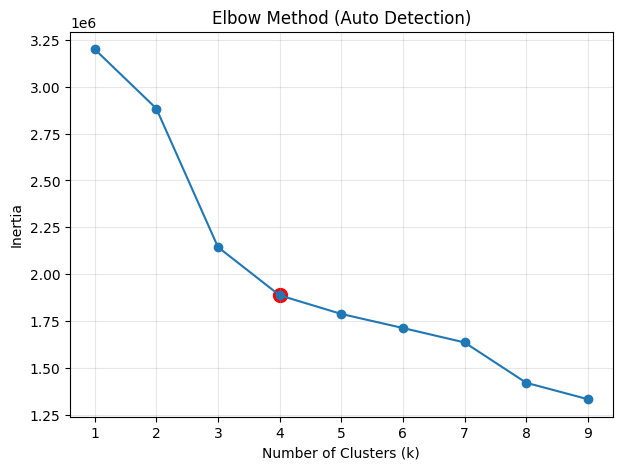

In [69]:
inertia = []
K = range(1, 10)

# Compute inertia
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Convert to numpy
K_vals = np.array(list(K))
inertia_vals = np.array(inertia)

# Line between first and last point
x1, y1 = K_vals[0], inertia_vals[0]
x2, y2 = K_vals[-1], inertia_vals[-1]

# Distance from each point to line
distances = []

for i in range(len(K_vals)):
    x0 = K_vals[i]
    y0 = inertia_vals[i]
    
    # distance formula
    dist = abs((y2 - y1)*x0 - (x2 - x1)*y0 + x2*y1 - y2*x1) / np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
    distances.append(dist)

# Find elbow
optimal_k = K_vals[np.argmax(distances)]
print(f"Optimal number of clusters: {optimal_k}")

# Plot
plt.figure(figsize=(7,5))
plt.plot(K_vals, inertia_vals, marker='o')
plt.scatter(optimal_k, inertia_vals[np.argmax(distances)], color='red', s=100)

plt.title('Elbow Method (Auto Detection)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(alpha=0.3)

plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
The elbow point is observed at k = 4, indicating that this is the optimal number of clusters.  
Beyond this point, adding more clusters does not significantly improve the model.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

### K-Means Clustering

After determining the optimal number of clusters, we apply the K-Means algorithm to group similar trips.

Each observation is assigned to a cluster based on similarity across the selected features.

This allows us to identify different types of Uber trips within the dataset.

In [70]:
# Apply KMeans with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)

# Assign clusters
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering completed!")
df[['fare_amount', 'distance_km', 'pickup_hour', 'cluster']].head()

Clustering completed!


,fare_amount,distance_km,pickup_hour,cluster
24238194,7.5,1.683323,19,3
27835199,7.7,2.457590,20,1
44984355,12.9,5.036377,21,1
25894730,5.3,1.661683,8,3
17610152,16.0,4.475450,17,1


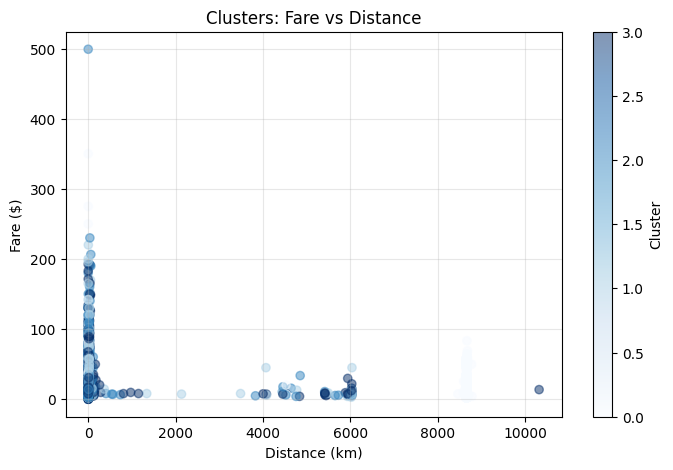

In [71]:
plt.figure(figsize=(8,5))

plt.scatter(df['distance_km'], df['fare_amount'],
            c=df['cluster'], cmap='Blues', alpha=0.5)

plt.xlabel('Distance (km)')
plt.ylabel('Fare ($)')
plt.title('Clusters: Fare vs Distance')

plt.colorbar(label='Cluster')
plt.grid(alpha=0.3)

plt.show()

In [72]:
cluster_summary = df.groupby('cluster')[['fare_amount', 'distance_km', 'pickup_hour', 'passenger_count']].mean()

print(cluster_summary)

         fare_amount  distance_km  pickup_hour  passenger_count
cluster                                                        
0          12.253698   773.127730    13.543243         1.663391
1          11.478770     4.857481    13.830535         1.666409
2          11.344615     5.242029    12.548682         1.771821
3          11.228485     5.061058    13.890902         1.634280
